Import libraries

In [24]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from tarnet import Tarnet
import sys
from pathlib import Path
project_root = Path("/home/ducm/Benchmark-conversion-vs-revenue-uplift-modeling/Revenue/Tarnet/main_tarnet.ipynb")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from utils import seed_everything
from metrics import auuc, auqc, lift, krcc

In [25]:
%time train_df = pd.read_csv(r"/home/ducm/Benchmark-conversion-vs-revenue-uplift-modeling/dataset/Hillstrom/Men/train_men.csv")
%time test_df =  pd.read_csv(r"/home/ducm/Benchmark-conversion-vs-revenue-uplift-modeling/dataset/Hillstrom/Men/test_men.csv")
%time val_df = pd.read_csv(r"/home/ducm/Benchmark-conversion-vs-revenue-uplift-modeling/dataset/Hillstrom/Men/val_men.csv")

CPU times: user 26.7 ms, sys: 6 ms, total: 32.7 ms
Wall time: 31.8 ms
CPU times: user 11 ms, sys: 2.99 ms, total: 13.9 ms
Wall time: 13.9 ms
CPU times: user 5.18 ms, sys: 997 μs, total: 6.18 ms
Wall time: 6.18 ms


In [26]:
in_features = ['recency', 'history_segment', 'history', 'mens', 'womens',
       'zip_code', 'newbie', 'channel_Multichannel', 'channel_Phone', 'channel_Web']
label_feature = ['spend']
treatment_feature = ['treatment']

In [27]:
X_train = train_df[in_features].values.astype(float) # type: ignore
y_train = train_df[label_feature].values.astype(float) # type: ignore
t_train = train_df[treatment_feature].values.astype(float) # type: ignore

X_test = test_df[in_features].values.astype(float) # type: ignore
y_test = test_df[label_feature].values.astype(float) # type: ignore
t_test = test_df[treatment_feature].values.astype(float) # type: ignore

X_val = val_df[in_features].values.astype(float) # type: ignore
y_val = val_df[label_feature].values.astype(float) # type: ignore
t_val = val_df[treatment_feature].values.astype(float) # type: ignore

In [28]:
print('X_train[:10]', X_train[:1].astype(float))

X_train[:10] [[-0.21435131  1.6331766   1.0667411   0.90252386 -1.1010233   1.07039981
   1.00043033  2.70003843 -0.88552759 -0.88616046]]


In [29]:
print('y_train[:10]', y_train[:1].astype(float))

y_train[:10] [[0.]]


In [30]:
# Transform to tensor
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

x_men_train_t = to_tensor(X_train)
x_men_val_t = to_tensor(X_val)
x_men_test_t = to_tensor(X_test)

y_men_train_t = to_tensor(y_train).reshape(-1, 1)
y_men_val_t = to_tensor(y_val).reshape(-1, 1)
y_men_test_t = to_tensor(y_test).reshape(-1, 1)

# t_train/t_val/t_test cũng tương tự
t_men_train_t = to_tensor(t_train.astype(float)).reshape(-1, 1)
t_men_val_t = to_tensor(t_val.astype(float)).reshape(-1, 1)
t_men_test_t = to_tensor(t_test.astype(float)).reshape(-1, 1)

# Data loader
train_dataset = TensorDataset(x_men_train_t, t_men_train_t, y_men_train_t)
val_dataset = TensorDataset(x_men_val_t, t_men_val_t, y_men_val_t)
test_dataset = TensorDataset(x_men_test_t, t_men_test_t, y_men_test_t)

batch_size = 6400
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory = True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory = True)

print("-------------------------------------------------------------")
print("✅ Completed transform to tensor ✅")
print(f"Shape of train: x={x_men_train_t.shape}; y={y_men_train_t.shape}; t={t_men_train_t.shape}")
print(f"Shape of val: x={x_men_val_t.shape}; y={y_men_val_t.shape}; t={t_men_val_t.shape}")
print(f"Shape of test: x={x_men_test_t.shape}; y={y_men_test_t.shape}; t={t_men_test_t.shape}")

-------------------------------------------------------------
✅ Completed transform to tensor ✅
Shape of train: x=torch.Size([25567, 10]); y=torch.Size([25567, 1]); t=torch.Size([25567, 1])
Shape of val: x=torch.Size([4262, 10]); y=torch.Size([4262, 1]); t=torch.Size([4262, 1])
Shape of test: x=torch.Size([12784, 10]); y=torch.Size([12784, 1]); t=torch.Size([12784, 1])


In [ ]:
epochs = 70
lr = 1e-4
wd = 1e-5
early_stop_metric = "qini"
ema = True
ema_alpha = 0.15
patience = 10
shared_dropout = 0
outcome_droupout = 0 
shared_hidden = 200
outcome_hidden = 100
early_stop_start = 0
activation = torch.nn.ReLU
print (f" epochs = {epochs}")
print (f" learning rate = {lr}")
print (f" weight decay = {wd}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")
print (f" shared hidden = {shared_hidden}")
print (f" outcome hidden = {outcome_hidden}")
print (f" early stop start = {early_stop_start}")
print (f" activation = {activation}")

 epochs = 70
 learning rate = 0.0001
 weight decay = 1e-05
 early stop = qini
 use ema = True
 ema alpha = 0.15
 patience = 10
 shared hidden = 200
 outcome hidden = 100
 early stop start = 0
 activation = <class 'torch.nn.modules.activation.ELU'>


Locked random seed: 412312
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/70 | Loss: 445.1520 | Val Loss: 498.7964 | Val Qini: 0.6073 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.6073 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/70 | Loss: 646.5122 | Val Loss: 498.5851 | Val Qini: 0.6533 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.6142 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/70 | Loss: 302.7013 | Val Loss: 498.3667 | Val Qini: 0.6760 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.6235 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/70 | Loss: 432.4787 | Val Loss: 498.1232 | Val Qini: 0.6932 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.6339 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/70 | Loss: 364.5932 | Val Loss: 497.8625 | Val Qini: 0.6997 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.6438 | ⭐ NEW BEST (peak ≥ trend)
Epoch 6/70 | Loss: 335

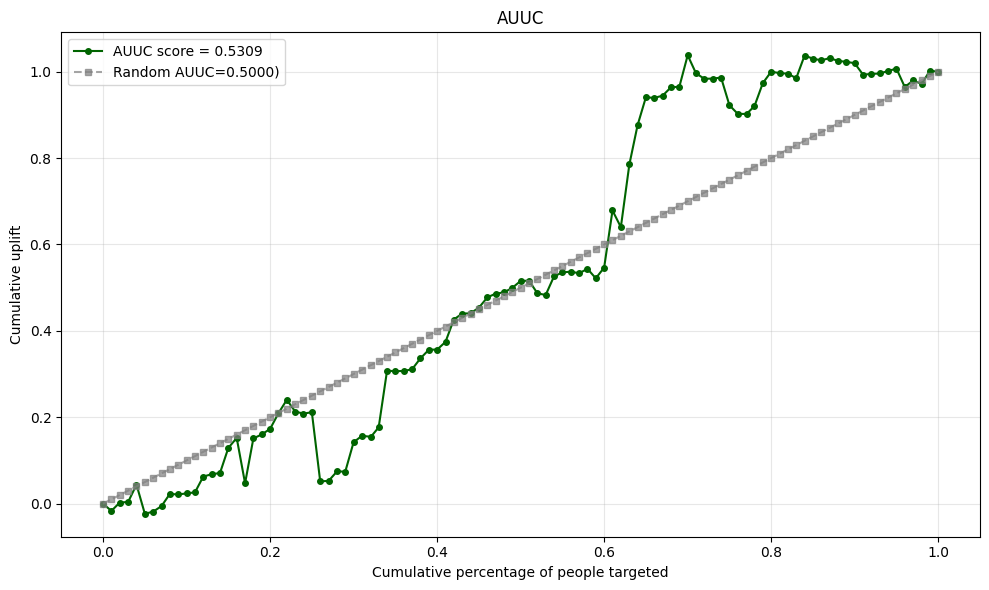

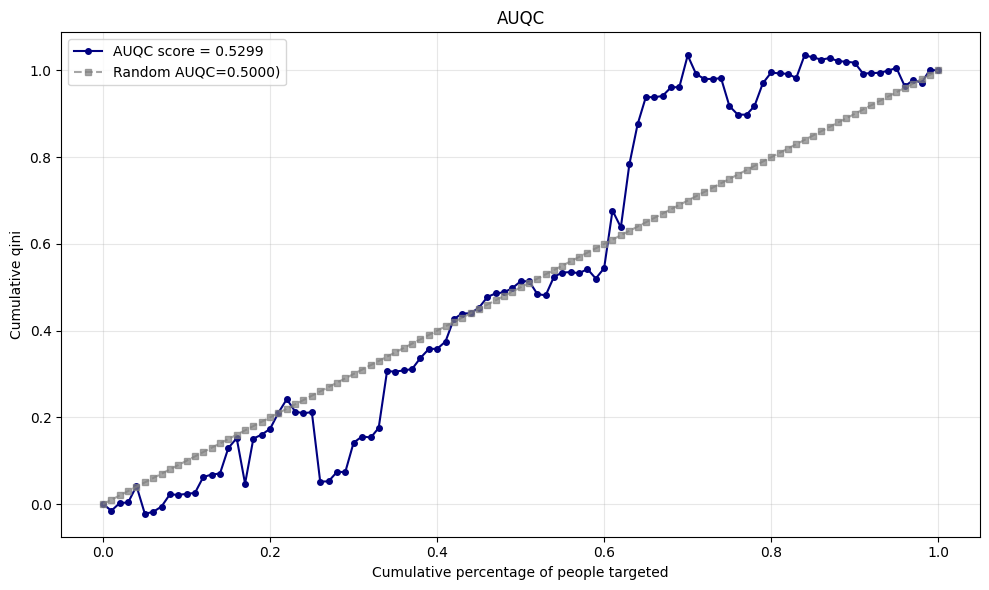

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.531
AUQC: 0.530
Lift: 0.277
KRCC: 0.129
ATE (predicted): 0.7329
ATE (true): 0.5874
ATE error: 0.1455


In [32]:
seed = 412312
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
                      activation=activation
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

Locked random seed: 42
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini


Epoch 1/70 | Loss: 340.1261 | Val Loss: 498.5723 | Val Qini: 0.7395 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.7395 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/70 | Loss: 606.1668 | Val Loss: 498.3868 | Val Qini: 0.7262 (patience: 1/10)EMA Trend: 0.7376 | (patience: 1/10)
Epoch 3/70 | Loss: 420.6032 | Val Loss: 498.1987 | Val Qini: 0.7126 (patience: 2/10)EMA Trend: 0.7338 | (patience: 2/10)
Epoch 4/70 | Loss: 478.0001 | Val Loss: 497.9987 | Val Qini: 0.7058 (patience: 3/10)EMA Trend: 0.7296 | (patience: 3/10)
Epoch 5/70 | Loss: 478.0766 | Val Loss: 497.7789 | Val Qini: 0.6947 (patience: 4/10)EMA Trend: 0.7244 | (patience: 4/10)
Epoch 6/70 | Loss: 174.0591 | Val Loss: 497.5303 | Val Qini: 0.6877 (patience: 5/10)EMA Trend: 0.7189 | (patience: 5/10)
Epoch 7/70 | Loss: 443.2584 | Val Loss: 497.2513 | Val Qini: 0.6842 (patience: 6/10)EMA Trend: 0.7137 | (patience: 6/10)
Epoch 8/70 | Loss: 343.6832 | Val Loss: 496.9439 | Val Qini: 0.6915 (patience: 7/10)EMA Trend: 0.7103 | (patience: 7/10)
Epoch 9/70 | L

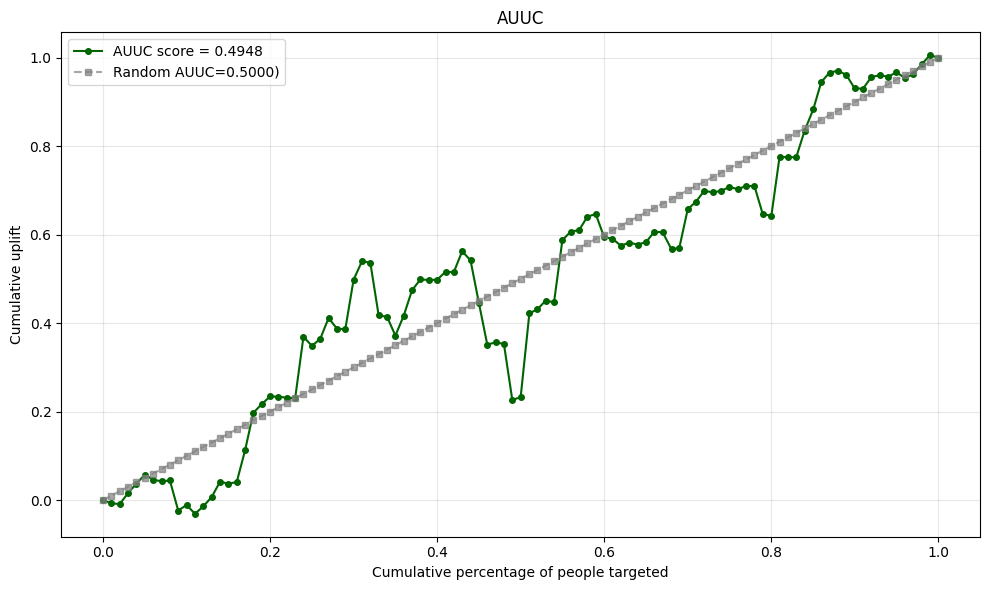

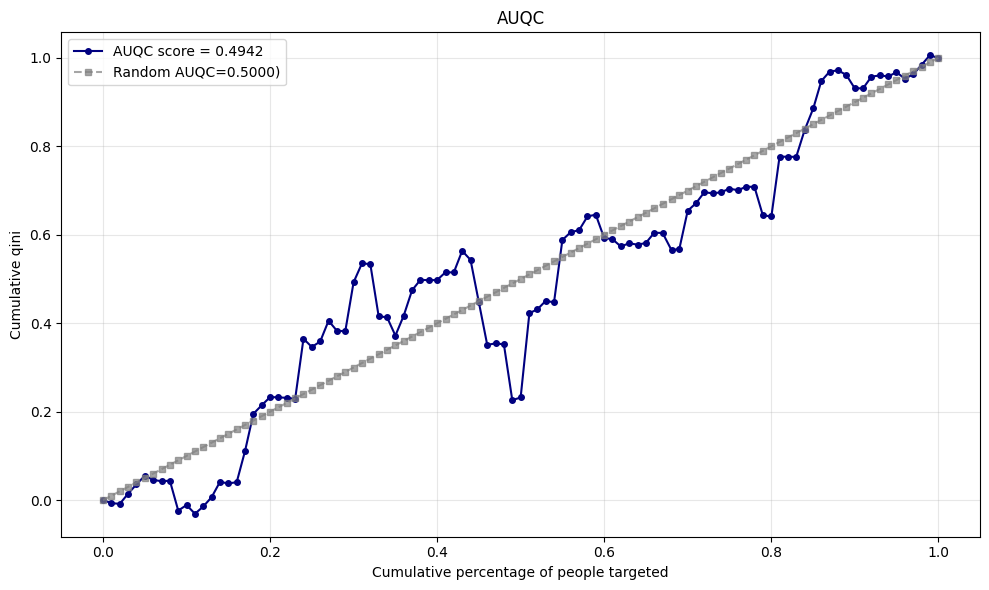

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.495
AUQC: 0.494
Lift: 0.975
KRCC: 0.007
ATE (predicted): -0.0607
ATE (true): 0.5874
ATE error: 0.6481


In [ ]:
seed = 42
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
                      activation=a`c`tivation

)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

Locked random seed: 1874
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/70 | Loss: 289.4502 | Val Loss: 498.4370 | Val Qini: 0.6120 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.6120 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/70 | Loss: 433.2513 | Val Loss: 498.2868 | Val Qini: 0.6132 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.6122 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/70 | Loss: 461.7510 | Val Loss: 498.1264 | Val Qini: 0.6030 (patience: 1/10)EMA Trend: 0.6108 | (patience: 1/10)
Epoch 4/70 | Loss: 340.4557 | Val Loss: 497.9560 | Val Qini: 0.5925 (patience: 2/10)EMA Trend: 0.6081 | (patience: 2/10)
Epoch 5/70 | Loss: 533.0134 | Val Loss: 497.7705 | Val Qini: 0.5821 (patience: 3/10)EMA Trend: 0.6042 | (patience: 3/10)
Epoch 6/70 | Loss: 577.9466 | Val Loss: 497.5562 | Val Qini: 0.5940 (patience:

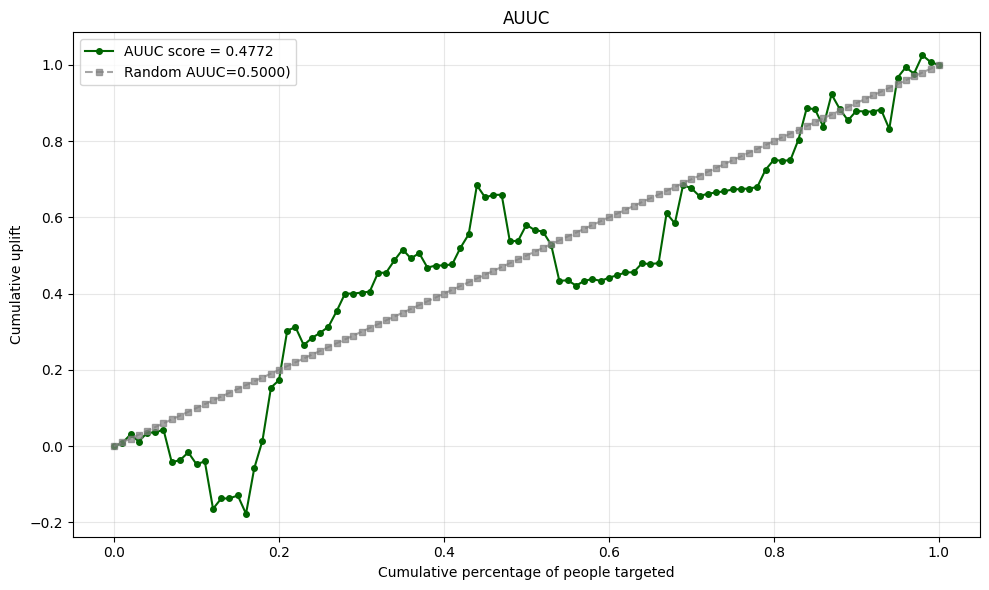

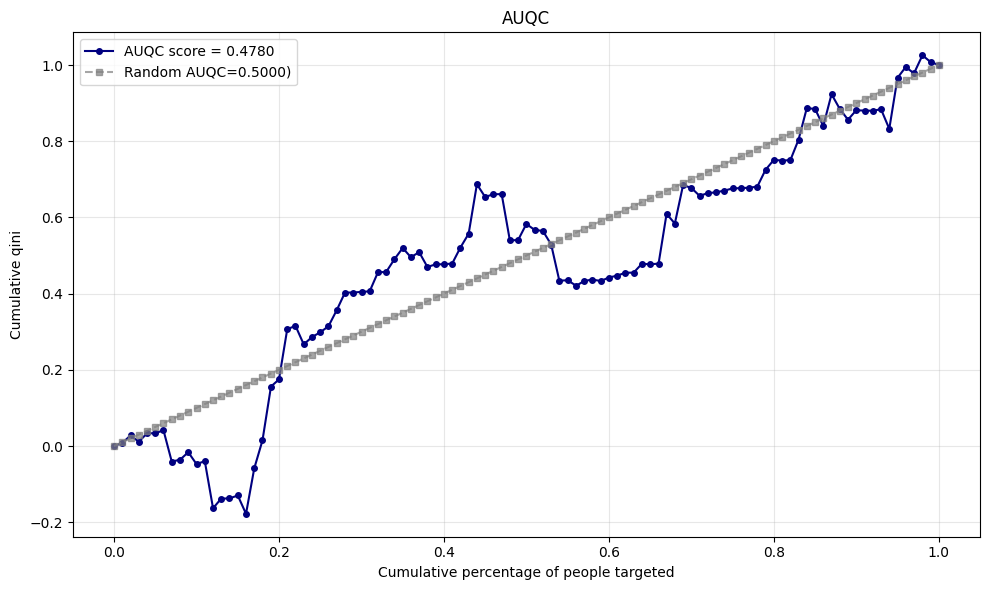

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.477
AUQC: 0.478
Lift: 0.789
KRCC: 0.075
ATE (predicted): 0.1324
ATE (true): 0.5874
ATE error: 0.4550


In [34]:
seed =1874
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
                      activation=activation
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

Locked random seed: 902745
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/70 | Loss: 532.8234 | Val Loss: 498.7111 | Val Qini: 0.2818 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2818 | ⭐ NEW BEST (peak ≥ trend)


Epoch 2/70 | Loss: 239.2435 | Val Loss: 498.5283 | Val Qini: 0.3019 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2848 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/70 | Loss: 554.4801 | Val Loss: 498.3424 | Val Qini: 0.3099 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.2886 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/70 | Loss: 535.0740 | Val Loss: 498.1461 | Val Qini: 0.3721 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.3011 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/70 | Loss: 352.1050 | Val Loss: 497.9279 | Val Qini: 0.4395 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.3219 | ⭐ NEW BEST (peak ≥ trend)
Epoch 6/70 | Loss: 297.2714 | Val Loss: 497.6915 | Val Qini: 0.4574 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.3422 | ⭐ NEW BEST (peak ≥ trend)
Epoch 7/70 | Loss: 381.7083 | Val Loss: 497.4310 | Val Qini: 0.5132 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.3678 | ⭐ NEW BEST (peak ≥ trend)
Epoch 8/70 | Loss: 604.3206 | Val Loss: 497.1514 | Val Qini: 0.5508 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.3953 | ⭐ NEW BEST (peak ≥ trend)
Epoch 9/70 | Loss: 470.9437

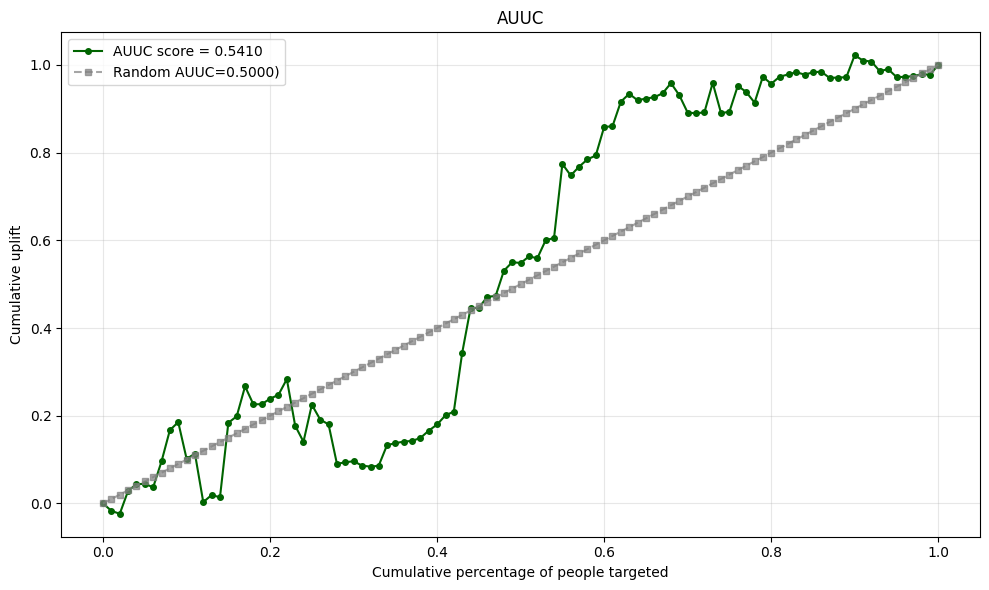

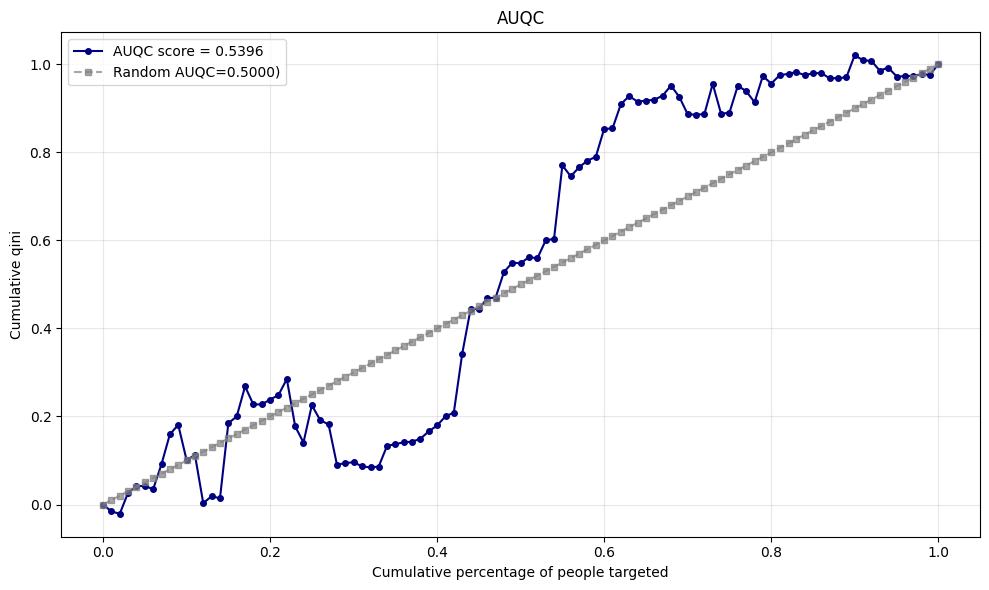

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.541
AUQC: 0.540
Lift: 0.189
KRCC: 0.076
ATE (predicted): 0.8138
ATE (true): 0.5874
ATE error: 0.2264


In [35]:
seed = 902745
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
                      activation=activation
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

Locked random seed: 1
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini


Epoch 1/70 | Loss: 301.1068 | Val Loss: 498.6840 | Val Qini: 0.3745 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.3745 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/70 | Loss: 405.2011 | Val Loss: 498.5236 | Val Qini: 0.3739 (patience: 1/10)EMA Trend: 0.3744 | (patience: 1/10)
Epoch 3/70 | Loss: 418.7887 | Val Loss: 498.3594 | Val Qini: 0.3772 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.3749 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/70 | Loss: 552.4800 | Val Loss: 498.1763 | Val Qini: 0.4099 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.3801 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/70 | Loss: 468.7499 | Val Loss: 497.9812 | Val Qini: 0.4235 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.3866 | ⭐ NEW BEST (peak ≥ trend)
Epoch 6/70 | Loss: 504.8305 | Val Loss: 497.7589 | Val Qini: 0.4554 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.3969 | ⭐ NEW BEST (peak ≥ trend)
Epoch 7/70 | Loss: 471.2795 | Val Loss: 497.5110 | Val Qini: 0.4784 ⭐ NEW BEST (peak ≥ trend)EMA Trend: 0.4092 | ⭐ NEW BEST (peak ≥ trend)
Epoch 8/70 | Loss: 324.8093 | Val Loss: 497.2

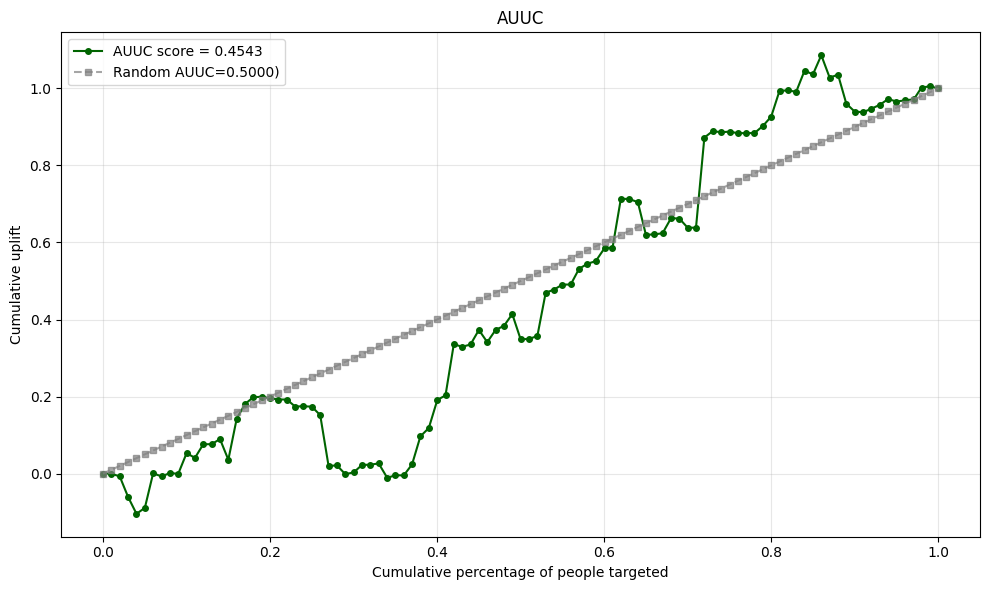

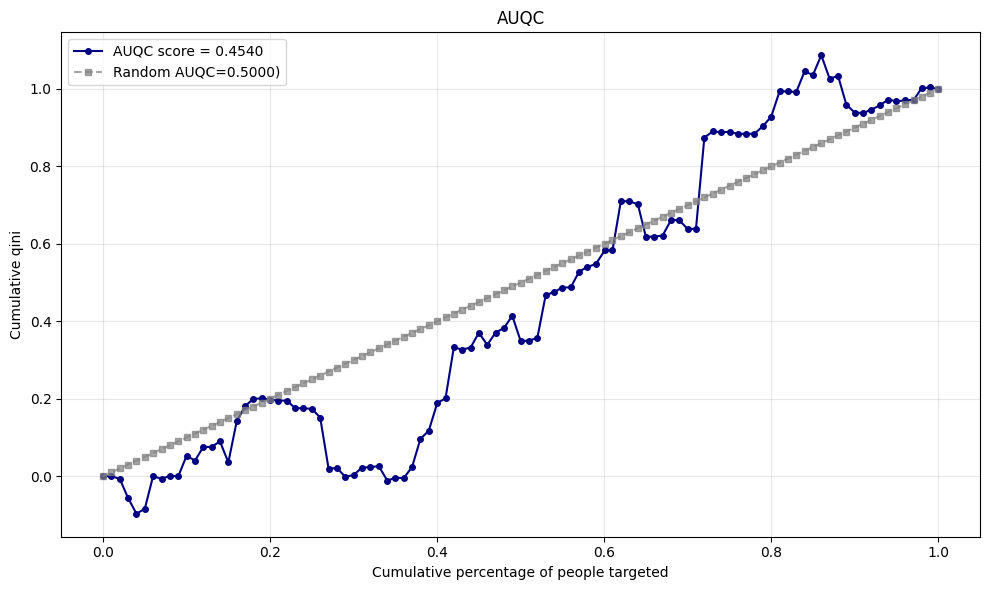

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.454
AUQC: 0.454
Lift: 0.006
KRCC: -0.015
ATE (predicted): 0.9159
ATE (true): 0.5874
ATE error: 0.3285


In [36]:
seed = 1
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
                      activation=activation
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")